# <div align="center">Bayesian Marketing Mix Models Meridian</div>

In [1]:
sensitivity = 0.90
specificity = 0.99
prior = 0.074
likelihood = sensitivity  # p(test|disease present)
marginal_likelihood = sensitivity * prior + (1 - specificity) * (1 - prior)
posterior = (likelihood * prior) / marginal_likelihood
posterior

0.8779330345373055

c:\Users\ACER\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


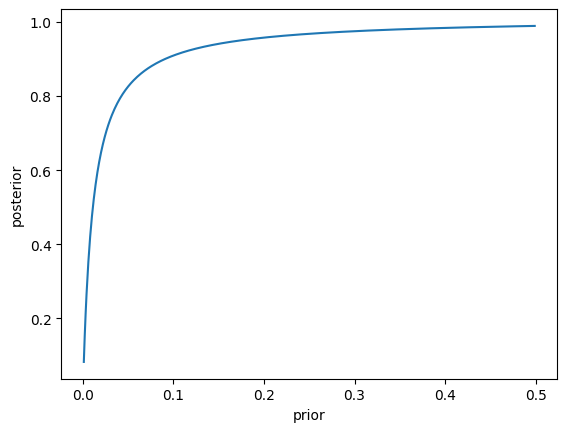

In [2]:
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt


def compute_posterior(prior, sensitivity, specificity):
    likelihood = sensitivity  # p(test|disease present)
    marginal_likelihood = sensitivity * prior + (1 - specificity) * (1 - prior)
    posterior = (likelihood * prior) / marginal_likelihood
    return(posterior)


prior_values = np.arange(0.001, 0.5, 0.001)
posterior_values = compute_posterior(prior_values, sensitivity, specificity)

plt.plot(prior_values, posterior_values)
plt.xlabel('prior')
_ = plt.ylabel('posterior')

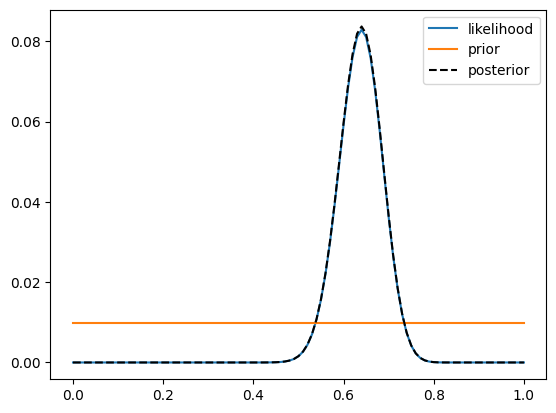

In [3]:
num_responders = 64
num_tested = 100

bayes_df = pd.DataFrame({'proportion': np.arange(0.0, 1.01, 0.01)})

# compute the binomial likelihood of the observed data for each
# possible value of proportion
bayes_df['likelihood'] = scipy.stats.binom.pmf(num_responders,
                                               num_tested,
                                               bayes_df['proportion'])
# The prior is equal for all possible values
bayes_df['prior'] = 1 / bayes_df.shape[0]

# compute the marginal likelihood by adding up the likelihood of each possible proportion times its prior probability.

marginal_likelihood = (bayes_df['likelihood'] * bayes_df['prior']).sum()

bayes_df['posterior'] = (bayes_df['likelihood'] * bayes_df['prior']) / marginal_likelihood

# plot the likelihood, prior, and posterior

plt.plot(bayes_df['proportion'], bayes_df['likelihood'], label='likelihood')
plt.plot(bayes_df['proportion'], bayes_df['prior'], label='prior')
plt.plot(bayes_df['proportion'], bayes_df['posterior'],
         'k--', label='posterior')

plt.legend()
plt.show()

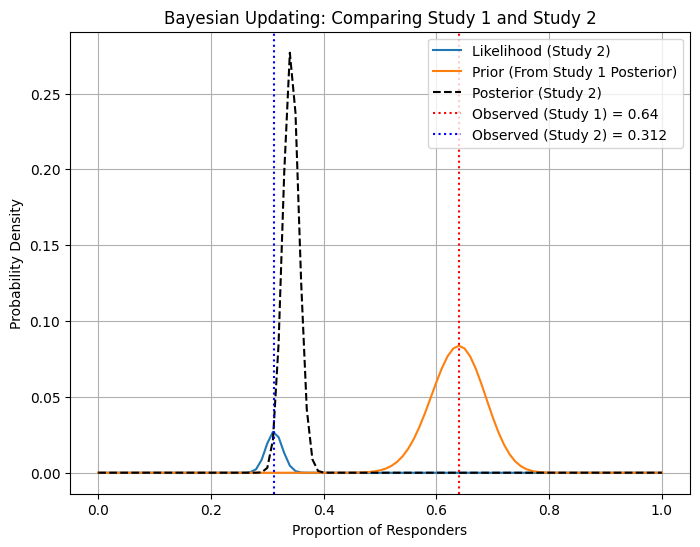

In [5]:
num_responders = 312
num_tested = 1000

# copy the posterior from the previous analysis and rename it as the prior

study2_df = bayes_df[['proportion', 'posterior']].rename(columns={'posterior': 'prior'})

# compute the binomial likelihood of the observed data for each
# possible value of proportion

study2_df['likelihood'] = scipy.stats.binom.pmf(num_responders,
                                               num_tested,
                                               study2_df['proportion'])

# compute the marginal likelihood by adding up the likelihood of each possible proportion times its prior probability.

marginal_likelihood = (study2_df['likelihood'] * study2_df['prior']).sum()

study2_df['posterior'] = (study2_df['likelihood'] * study2_df['prior']) / marginal_likelihood

plt.figure(figsize=(8, 6))

# Plot the likelihood, prior, and posterior
plt.plot(study2_df['proportion'], study2_df['likelihood'], label='Likelihood (Study 2)')
plt.plot(study2_df['proportion'], study2_df['prior'], label='Prior (From Study 1 Posterior)')
plt.plot(study2_df['proportion'], study2_df['posterior'], 'k--', label='Posterior (Study 2)')

# Add vertical lines for observed values in both studies
plt.axvline(x=64/100, color='red', linestyle=':', label='Observed (Study 1) = 0.64')
plt.axvline(x=312/1000, color='blue', linestyle=':', label='Observed (Study 2) = 0.312')

# Add labels and legend
plt.xlabel('Proportion of Responders')
plt.ylabel('Probability Density')
plt.title('Bayesian Updating: Comparing Study 1 and Study 2')
plt.legend()
plt.grid(True)

plt.show()
